# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 39     |  |
| :-------------|:-------------|
| Edzard Inia | 6519083 |
| Jochem van den Boomen | 6527620 |
| Felicie van der Leij | 6210392 |

| Planning Groep: 39     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | Voor lunch |
| Mijlpaal 2: Eerste kalibratie meting gedaan| Voor lunch |
| Pauze 1| 12:30-13:45 |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Foto van alle schetsen.

Alle 27 schetsen van de 3 verschillende sensoren
 ![Alt](schetsen.jpg "schets student")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.


| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Lichtsensor | Thermistor om lichtinval te beoordelen voor het automatisch bedienen van straatverlichting | De sensor schakelt de verlichting in bij < 100 lux en uit bij > 300 lux, met een meetafwijking van maximaal ±10%, binnen 1 seconde na verandering van lichtintensiteit.|
|Thermistor | Temperatuurmeting om koorts te bepalen | De sensor meet lichaamstemperatuur in het bereik 35–42 °C met een maximale afwijking van ±0,1 °C en geeft binnen 5 seconden een stabiele waarde weer.|
|Druksensor | Gewichtsmeting om massa te bepalen | De sensor meet massa in het bereik 0–5 kg met een maximale afwijking van ±5%, waarbij de meetwaarde binnen 2 seconden stabiel is |

Groep 39 heeft gekozen voor de lichtgevoelige sensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Schets van de caddy met de opstelling in het bovenste vak
 ![Alt](schetsmeetopstelling.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
Lichtinval bij verandering van afstand lichtbron
2. Over welk bereik ga je deze variabelen veranderen?
Afstand 0-30 cm
3. Wat ga je allemaal meten?
Analoge Arduino waarde, lux in phyphox
4. Hoeveel metingen ga je doen?
10 metingen
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Ja



## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Dit is onze meetopstelling. Links op de foto zien we, in de donkere caddy, de zaklamp van een smartphone welke gebruikt is als lichtbron in dit experiment. Het breadbord is recht tegenover de lichtbron geplaatst. De afstand tussen de LDR en de zaklamp wordt met een meetlint bepaald. Met meetintervallen van 3cm wordt eerst de analoge weerstandswaarde gemeten en vervolgens op dezelfde positie de lux met behulp van phyphox.
 ![Alt](bord.jpg "bord")
 ![Alt](meetopstelling.jpg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

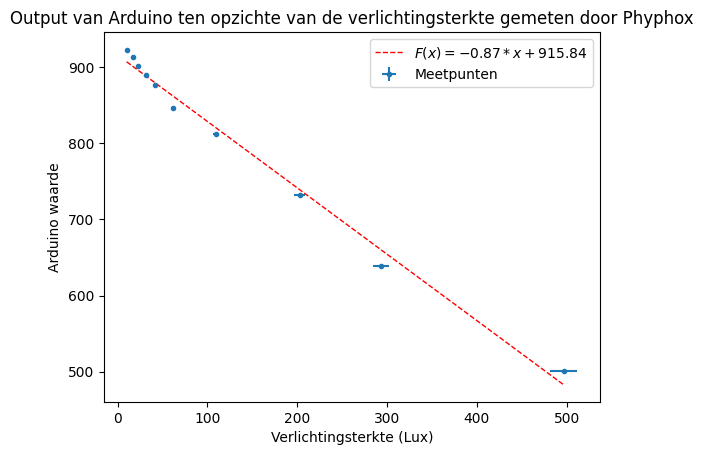

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
Verlichtingsterkte = np.array([497,293,203,110,62,42,32,23,17,10])
Weerstand = np.array([501,639,732,812,846,876,890,902,914,923])

def func(x,a,b):
    return a*x+b

popt,pcov=curve_fit(func, Verlichtingsterkte,Weerstand)

x=np.linspace(min(Verlichtingsterkte),max(Verlichtingsterkte),1000)
y=func(x,*popt)

plt.figure()
plt.errorbar(Verlichtingsterkte,Weerstand, xerr=0.03*Verlichtingsterkte, yerr=1, fmt=".", label='Meetpunten')
plt.plot(x,y,"r--", linewidth=1, label="$F(x)= %.2f *x + %0.2f$" %(popt[0],popt[1]))
plt.xlabel("Verlichtingsterkte (Lux)")
plt.ylabel("Arduino waarde")
plt.title('Output van Arduino ten opzichte van de verlichtingsterkte gemeten door Phyphox')
plt.legend()
plt.show()


Na de iteratie hebben we een tweede proef gedaan waar we binnen een seconde finger op de lichtsensor hebben geplaatst, wat een verandering in de lichtinstroom veroorzaakt, en gekeken bij de output op onze laptop of die verandering binnen één seconde wordt gemeten. We hebben een timer erbij gezet. We kunnen meteen zien dat er bij sneller dan één seconde een verandering op de laptop wordt aangetoont van ongeveer 850 Arduino waarde naar 960 Arduino waarde.

## *Opdracht 7*: Iteratie nodig?

Op basis van onze metingen kunnen we concluderen dat er aan de eerste twee criteria wordt voldaan. Voor het derde criterium, of de LDR een lichtsintensiteitsverandering binnen een seconde kan meten, moeten we nog een proef doen. Deze houdt in dat je lichtsensor weer aan je laptop aansluit via Arduino, en dat je een keer binnen een seconde je finger tegen de lichtsensor drukt en vervolgens kijkt op de laptop of Arduino een keer een andere waarde aangeeft (omdat je je finger eraan hebt gedrukt). Als dat gebeurd dan kunnen concluderen dat er binnen 1 secondeeen verandering van lichtintensiteit kan gemeten worden. Voor de rest is er geen iteratie nodig.

## *Opdracht 8*: Conclusie, leerdoel

Na de resultaten te hebben bekeken kunnen we concluderen dat aan de eerste twee criteria is voldaan. De sensor kan boven en onder 100 en 300 lux meten, dus het is mogelijk om het licht aan en uit te laten gaan rond die lux waardes. Phypox had een meeterrorwaarde van rond de 3% bij elke meting en Arduino had een error van 1 (1 Arduino waarde), dus ook aan het criterium van een maximale error van 10% is ruimschoots voldaan. Voor het derde criterium hebben we al een proef klaarstaan, dus ook aan deze zal voldaan worden. Dus wij kunnen concluderen dat de lichtsensor geschikt is voor ons idee.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

 ![Alt](bord.jpg "bord")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.


| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Lichtsensor | Thermistor om lichtinval te beoordelen voor het automatisch bedienen van straatverlichting | De sensor schakelt de verlichting in bij < 100 lux en uit bij > 300 lux, met een meetafwijking van maximaal ±10%, binnen 1 seconde na verandering van lichtintensiteit.|
|Thermistor | Temperatuurmeting om koorts te bepalen | De sensor meet lichaamstemperatuur in het bereik 35–42 °C met een maximale afwijking van ±0,1 °C en geeft binnen 5 seconden een stabiele waarde weer.|
|Druksensor | Gewichtsmeting om massa te bepalen | De sensor meet massa in het bereik 0–5 kg met een maximale afwijking van ±5%, waarbij de meetwaarde binnen 2 seconden stabiel is |

Groep 39 heeft gekozen voor de lichtgevoelige sensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing, een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Dit is onze meetopstelling. Links op de foto zien we, in de donkere caddy, de zaklamp van een smartphone welke gebruikt is als lichtbron in dit experiment. Het breadbord is recht tegenover de lichtbron geplaatst. De afstand tussen de LDR en de zaklamp wordt met een meetlint bepaald. Met meetintervallen van 3cm wordt eerst de analoge weerstandswaarde gemeten en vervolgens op dezelfde positie de lux met behulp van phyphox.
 ![Alt](bord.jpg "bord")
 ![Alt](meetopstelling.jpg "meetopstelling student")


Na de resultaten te hebben bekeken kunnen we concluderen dat aan de eerste twee criteria is voldaan. De sensor kan boven en onder 100 en 300 lux meten, dus het is mogelijk om het licht aan en uit te laten gaan rond die lux waardes. Phypox had een meeterrorwaarde van rond de 3% bij elke meting en Arduino had een error van 1 (1 Arduino waarde), dus ook aan het criterium van een maximale error van 10% is ruimschoots voldaan. Voor het derde criterium hebben we al een proef klaarstaan, dus ook aan deze zal voldaan worden. Dus wij kunnen concluderen dat de lichtsensor geschikt is voor ons idee.

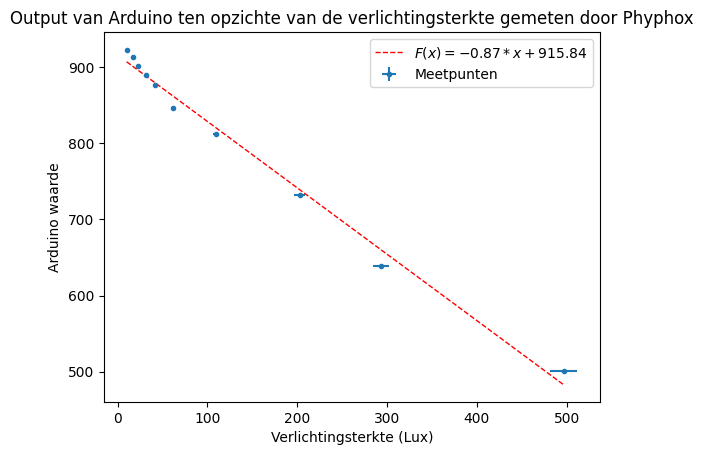

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
Verlichtingsterkte = np.array([497,293,203,110,62,42,32,23,17,10])
Weerstand = np.array([501,639,732,812,846,876,890,902,914,923])

def func(x,a,b):
    return a*x+b

popt,pcov=curve_fit(func, Verlichtingsterkte,Weerstand)

x=np.linspace(min(Verlichtingsterkte),max(Verlichtingsterkte),1000)
y=func(x,*popt)

#plt.figure()
plt.errorbar(Verlichtingsterkte,Weerstand, xerr=0.03*Verlichtingsterkte, yerr=1, fmt=".", label='Meetpunten')
plt.plot(x,y,"r--", linewidth=1, label="$F(x)= %.2f *x + %0.2f$" %(popt[0],popt[1]))
plt.xlabel("Verlichtingsterkte (Lux)")
plt.ylabel("Arduino waarde")
plt.title('Output van Arduino ten opzichte van de verlichtingsterkte gemeten door Phyphox')
plt.legend()

